## 1. Environment Setup and Library Imports

In this section, the required Python libraries are imported for data processing, visualization, model development, training, and evaluation. The available computing device is also checked to determine whether GPU acceleration can be used.

In [2]:
import os
import json
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.models as models

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Dataset Path Configuration

This section defines the file paths for the COCO 2017 Keypoints dataset. The training and validation image directories and their corresponding annotation files are specified so that the dataset can be loaded correctly in the following steps.

In [3]:
DATA_DIR = "/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017"

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train2017")
VAL_IMG_DIR = os.path.join(DATA_DIR, "val2017")

TRAIN_ANN = os.path.join(DATA_DIR, "annotations", "person_keypoints_train2017.json")
VAL_ANN = os.path.join(DATA_DIR, "annotations", "person_keypoints_val2017.json")

print("Train image directory:", TRAIN_IMG_DIR)
print("Validation image directory:", VAL_IMG_DIR)
print("Train annotation file:", TRAIN_ANN)
print("Validation annotation file:", VAL_ANN)

Train image directory: /kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/train2017
Validation image directory: /kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017
Train annotation file: /kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/annotations/person_keypoints_train2017.json
Validation annotation file: /kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/annotations/person_keypoints_val2017.json


## 3. Loading COCO Annotation Information

This section loads the COCO training annotation file and displays the basic structure of the dataset. The number of training images, number of annotations, and the list of 17 human body keypoints are printed to verify that the dataset is loaded correctly.

In [4]:
with open(TRAIN_ANN, "r") as f:
    train_data = json.load(f)

print(train_data.keys())
print("Number of train images:", len(train_data["images"]))
print("Number of train annotations:", len(train_data["annotations"]))
print("Keypoints:", train_data["categories"][0]["keypoints"])

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
Number of train images: 118287
Number of train annotations: 262465
Keypoints: ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']


## 4. Visualization of Sample Images and Keypoints

This section visualizes representative images from the COCO 2017 Keypoints dataset together with their annotated human body keypoints. These examples help illustrate the diversity of human poses, viewpoints, and scene conditions in the dataset.

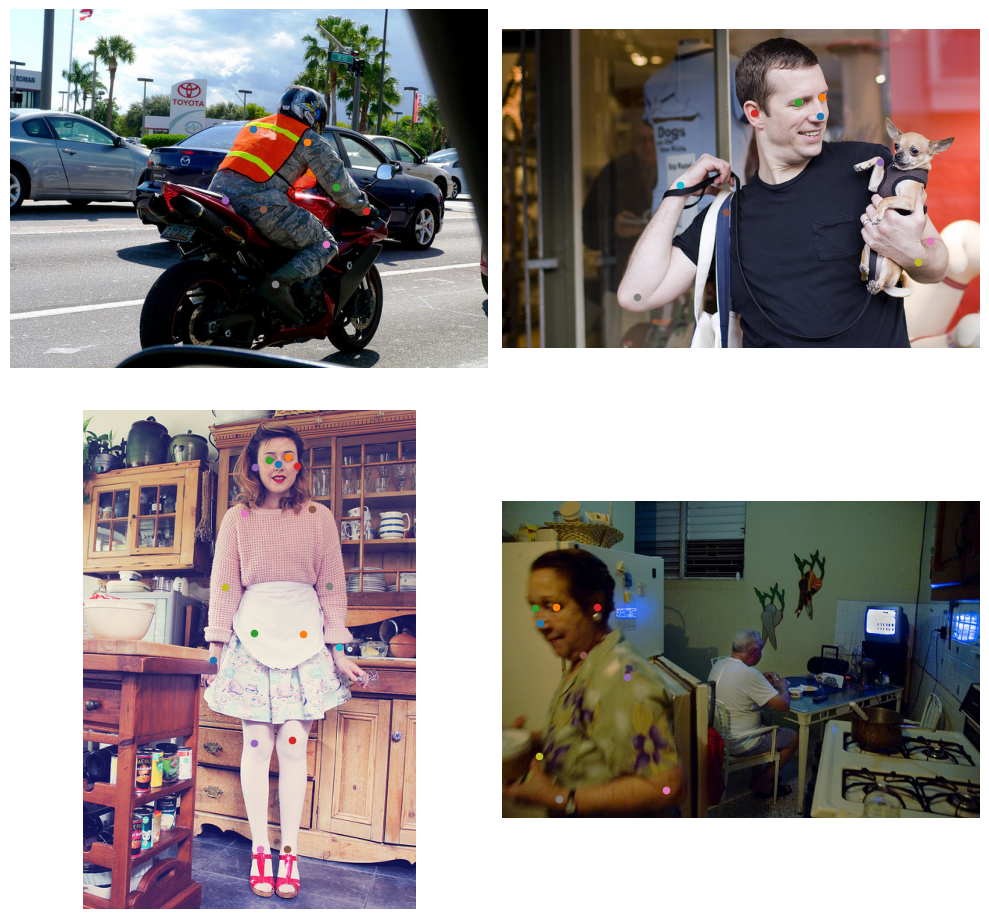

In [36]:
# ============================================================
# Multiple COCO Sample Images with Keypoints
# ============================================================

images_dict = {img["id"]: img for img in train_data["images"]}

valid_annotations = [
    ann for ann in train_data["annotations"]
    if ann["num_keypoints"] > 0
]

sample_ids = [0, 50, 100, 150]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, idx in zip(axes.flatten(), sample_ids):

    ann = valid_annotations[idx]

    img_info = images_dict[ann["image_id"]]

    img_path = os.path.join(
        TRAIN_IMG_DIR,
        img_info["file_name"]
    )

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    keypoints = np.array(
        ann["keypoints"]
    ).reshape(-1, 3)

    ax.imshow(image)

    for x, y, v in keypoints:
        if v > 0:
            ax.scatter(x, y, s=20)

    ax.axis("off")

plt.tight_layout()
plt.savefig(
    "/kaggle/working/multiple_coco_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Heatmap Generation for Keypoints

This section defines the image size, heatmap resolution, number of keypoints, and Gaussian spread value used in the project. The `generate_heatmaps` function converts each visible keypoint coordinate into a 2D Gaussian heatmap, which is used as the target output during model training.

In [6]:
IMG_SIZE = 256
HEATMAP_SIZE = 64
NUM_KEYPOINTS = 17
SIGMA = 2

def generate_heatmaps(keypoints, original_w, original_h):
    heatmaps = np.zeros((NUM_KEYPOINTS, HEATMAP_SIZE, HEATMAP_SIZE), dtype=np.float32)

    for i, (x, y, v) in enumerate(keypoints):
        if v > 0:
            x = x * HEATMAP_SIZE / original_w
            y = y * HEATMAP_SIZE / original_h

            xx, yy = np.meshgrid(
                np.arange(HEATMAP_SIZE),
                np.arange(HEATMAP_SIZE)
            )

            heatmap = np.exp(
                -((xx - x) ** 2 + (yy - y) ** 2) / (2 * SIGMA ** 2)
            )

            heatmaps[i] = heatmap

    return heatmaps

## 6. Custom COCO Pose Dataset and Data Augmentation

This section defines a custom PyTorch dataset class for loading COCO keypoint images and annotations. The dataset class reads image files, extracts visible keypoints, applies image transformations, and generates target heatmaps for training. During training, horizontal flip augmentation is also applied with correct left-right keypoint swapping to preserve anatomical consistency.

In [7]:
COCO_FLIP_PAIRS = [
    (1, 2),    # left_eye, right_eye
    (3, 4),    # left_ear, right_ear
    (5, 6),    # left_shoulder, right_shoulder
    (7, 8),    # left_elbow, right_elbow
    (9, 10),   # left_wrist, right_wrist
    (11, 12),  # left_hip, right_hip
    (13, 14),  # left_knee, right_knee
    (15, 16)   # left_ankle, right_ankle
]

class COCOPoseDataset(Dataset):
    def __init__(self, img_dir, ann_path, max_samples=5000, train=True):
        self.img_dir = img_dir
        self.train = train

        with open(ann_path, "r") as f:
            data = json.load(f)

        self.images = {img["id"]: img for img in data["images"]}

        anns = [
            ann for ann in data["annotations"]
            if ann["num_keypoints"] > 0
        ]

        random.seed(42)
        random.shuffle(anns)

        self.annotations = anns[:max_samples]

        self.transform = T.Compose([
            T.ToPILImage(),
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.annotations)

    def horizontal_flip(self, image, keypoints):
        h, w, _ = image.shape

        image = cv2.flip(image, 1)

        keypoints = keypoints.copy()

        for i in range(NUM_KEYPOINTS):
            if keypoints[i, 2] > 0:
                keypoints[i, 0] = w - keypoints[i, 0] - 1

        for left, right in COCO_FLIP_PAIRS:
            keypoints[[left, right]] = keypoints[[right, left]]

        return image, keypoints

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_info = self.images[ann["image_id"]]

        img_path = os.path.join(self.img_dir, img_info["file_name"])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w, _ = image.shape

        keypoints = np.array(ann["keypoints"]).reshape(-1, 3)

        if self.train and random.random() < 0.5:
            image, keypoints = self.horizontal_flip(image, keypoints)

        heatmaps = generate_heatmaps(keypoints, w, h)

        image = self.transform(image)
        heatmaps = torch.tensor(heatmaps, dtype=torch.float32)

        return image, heatmaps

## 7. Dataset and DataLoader Preparation

This section creates the training and validation datasets using the custom COCO pose dataset class. A subset of 5,000 training samples and 500 validation samples is used due to computational limitations. DataLoaders are then prepared with a batch size of 16 for model training and evaluation.

In [8]:
train_dataset = COCOPoseDataset(
    img_dir=TRAIN_IMG_DIR,
    ann_path=TRAIN_ANN,
    max_samples=5000,
    train=True
)

val_dataset = COCOPoseDataset(
    img_dir=VAL_IMG_DIR,
    ann_path=VAL_ANN,
    max_samples=500,
    train=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

images, heatmaps = next(iter(train_loader))

print("Image batch:", images.shape)
print("Heatmap batch:", heatmaps.shape)

Train samples: 5000
Validation samples: 500
Image batch: torch.Size([16, 3, 256, 256])
Heatmap batch: torch.Size([16, 17, 64, 64])


## 8. Baseline ResNet18 Pose Estimation Model

This section defines the baseline pose estimation model. The architecture uses an ImageNet-pretrained ResNet18 backbone for feature extraction, followed by three deconvolution layers to recover spatial resolution and a final 1 × 1 convolution layer to predict 17 keypoint heatmaps.

In [9]:
class ResNet18PoseBaseline(nn.Module):
    def __init__(self, num_keypoints=17):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4
        )

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.head = nn.Conv2d(64, num_keypoints, kernel_size=1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.deconv(x)
        x = self.head(x)
        return x

## 9. Convolutional Block Attention Module

This section defines the Convolutional Block Attention Module (CBAM), which is composed of channel attention and spatial attention. Channel attention helps the model emphasize important feature channels, while spatial attention highlights informative regions in the feature maps.

In [10]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, kernel_size=1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))

        out = avg_out + max_out

        return self.sigmoid(out)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=7,
            padding=3,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)

        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x_cat = torch.cat([avg_out, max_out], dim=1)

        return self.sigmoid(self.conv(x_cat))


class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.channel_attention = ChannelAttention(channels)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)

        return x

## 10. Proposed ResNet18 + CBAM Pose Estimation Model

This section defines the proposed CBAM-enhanced pose estimation model. The architecture uses the same ImageNet-pretrained ResNet18 backbone as the baseline model, but adds a CBAM attention module after the backbone to refine feature representations before the deconvolution layers and final heatmap prediction head.

In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline_model = ResNet18PoseBaseline().to(device)
cbam_model = ResNet18CBAMPose().to(device)

sample_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)

baseline_output = baseline_model(sample_input)
cbam_output = cbam_model(sample_input)

print("Baseline output shape:", baseline_output.shape)
print("CBAM output shape:", cbam_output.shape)

baseline_params = count_parameters(baseline_model)
cbam_params = count_parameters(cbam_model)

print("Baseline parameters:", baseline_params)
print("CBAM parameters:", cbam_params)
print("Extra parameters:", cbam_params - baseline_params)
print("Extra parameter ratio:", ((cbam_params - baseline_params) / baseline_params) * 100)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s] 


Baseline output shape: torch.Size([2, 17, 64, 64])
CBAM output shape: torch.Size([2, 17, 64, 64])
Baseline parameters: 13931473
CBAM parameters: 13964339
Extra parameters: 32866
Extra parameter ratio: 0.2359118809619055


## 11. Training and Validation Functions

This section defines the functions used for one training epoch and one validation epoch. The training function updates the model parameters using backpropagation, while the validation function evaluates the model without updating the weights. Both functions return the average MSE loss for each epoch.

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0

    for images, heatmaps in tqdm(loader):
        images = images.to(device)
        heatmaps = heatmaps.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, heatmaps)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0

    with torch.no_grad():
        for images, heatmaps in tqdm(loader):
            images = images.to(device)
            heatmaps = heatmaps.to(device)

            outputs = model(images)

            loss = criterion(outputs, heatmaps)

            running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss

## 13. Training the Baseline ResNet18 Model

This section trains the baseline ResNet18 pose estimation model for 15 epochs using MSE loss and the Adam optimizer. Training and validation losses are recorded at each epoch, and the trained model weights are saved after training.

In [14]:
baseline_model = ResNet18PoseBaseline().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=1e-4
)

EPOCHS = 15

baseline_train_losses = []
baseline_val_losses = []

for epoch in range(EPOCHS):
    print(f"\nBaseline Epoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        baseline_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate_one_epoch(
        baseline_model,
        val_loader,
        criterion,
        device
    )

    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.6f}")
    print(f"Validation Loss: {val_loss:.6f}")

torch.save(
    baseline_model.state_dict(),
    "/kaggle/working/baseline_resnet18_5000_15epoch.pth"
)

print("Baseline model saved.")


Baseline Epoch 1/15


100%|██████████| 32/32 [00:05<00:00,  6.12it/s]


Train Loss: 0.009111
Validation Loss: 0.002306

Baseline Epoch 2/15


100%|██████████| 32/32 [00:03<00:00, 10.30it/s]


Train Loss: 0.002157
Validation Loss: 0.002046

Baseline Epoch 3/15


...

Train Loss: 0.001902
Validation Loss: 0.001940

Baseline Epoch 14/15


100%|██████████| 32/32 [00:03<00:00, 10.27it/s]


Train Loss: 0.001868
Validation Loss: 0.001931

Baseline Epoch 15/15


100%|██████████| 32/32 [00:03<00:00, 10.55it/s]

Train Loss: 0.001837
Validation Loss: 0.001911
Baseline model saved.


## 14. Training the ResNet18 + CBAM Model

This section trains the proposed ResNet18 + CBAM pose estimation model for 15 epochs using the same optimizer, learning rate, loss function, batch size, and dataset split as the baseline model. The training and validation losses are recorded for comparison, and the trained model weights are saved after training.

In [15]:
cbam_model = ResNet18CBAMPose().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    cbam_model.parameters(),
    lr=1e-4
)

EPOCHS = 15

cbam_train_losses = []
cbam_val_losses = []

for epoch in range(EPOCHS):
    print(f"\nCBAM Epoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        cbam_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate_one_epoch(
        cbam_model,
        val_loader,
        criterion,
        device
    )

    cbam_train_losses.append(train_loss)
    cbam_val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.6f}")
    print(f"Validation Loss: {val_loss:.6f}")

torch.save(
    cbam_model.state_dict(),
    "/kaggle/working/cbam_resnet18_5000_15epoch.pth"
)

print("CBAM model saved.")


CBAM Epoch 1/15


100%|██████████| 32/32 [00:03<00:00, 10.33it/s]


Train Loss: 0.008059
Validation Loss: 0.002180

CBAM Epoch 2/15


100%|██████████| 32/32 [00:03<00:00,  9.90it/s]


Train Loss: 0.002121
Validation Loss: 0.002005

CBAM Epoch 3/15


...

Train Loss: 0.001728
Validation Loss: 0.001887

CBAM Epoch 14/15


100%|██████████| 32/32 [00:03<00:00, 10.27it/s]


Train Loss: 0.001674
Validation Loss: 0.001869

CBAM Epoch 15/15


100%|██████████| 32/32 [00:03<00:00, 10.31it/s]

Train Loss: 0.001617
Validation Loss: 0.001899
CBAM model saved.


## 15. Validation Loss Comparison

This section plots the validation loss curves of the baseline ResNet18 model and the ResNet18 + CBAM model across 15 training epochs. The figure is saved for use in the final report and helps compare the validation performance of both architectures.

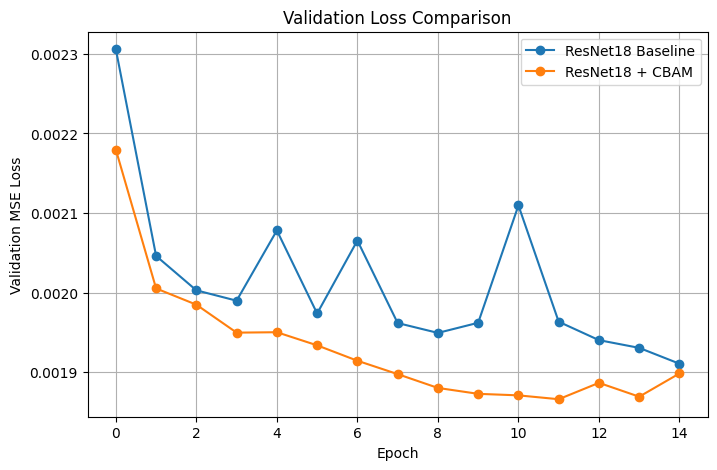

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_val_losses,
    label="ResNet18 Baseline",
    marker="o"
)

plt.plot(
    cbam_val_losses,
    label="ResNet18 + CBAM",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)

plt.savefig(
    "/kaggle/working/validation_loss_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 16. Final Quantitative Results Table

This section creates the final comparison table for the baseline ResNet18 model and the ResNet18 + CBAM model. The table summarizes the dataset size, number of epochs, trainable parameters, additional parameters introduced by CBAM, final training loss, and final validation loss.

In [17]:
baseline_params = count_parameters(baseline_model)
cbam_params = count_parameters(cbam_model)

results_df = pd.DataFrame({
    "Model": [
        "ResNet18 Baseline",
        "ResNet18 + CBAM"
    ],
    "Train Samples": [
        5000,
        5000
    ],
    "Validation Samples": [
        500,
        500
    ],
    "Epochs": [
        15,
        15
    ],
    "Parameters": [
        baseline_params,
        cbam_params
    ],
    "Extra Parameters": [
        0,
        cbam_params - baseline_params
    ],
    "Final Train Loss": [
        baseline_train_losses[-1],
        cbam_train_losses[-1]
    ],
    "Final Validation Loss": [
        baseline_val_losses[-1],
        cbam_val_losses[-1]
    ]
})

results_df

,Model,Train Samples,Validation Samples,Epochs,Parameters,Extra Parameters,Final Train Loss,Final Validation Loss
0,ResNet18 Baseline,5000,500,15,13931473,0,0.001837,0.001911
1,ResNet18 + CBAM,5000,500,15,13964339,32866,0.001617,0.001899


## 17. Saving the Final Results

This section saves the final quantitative comparison table as a CSV file. The exported file can be used for reporting, documentation, and reproducibility.

In [18]:
results_df.to_csv(
    "/kaggle/working/final_results.csv",
    index=False
)

print("Results table saved as final_results.csv")

Results table saved as final_results.csv


## 18. Converting Heatmaps to Keypoint Coordinates

This section defines a helper function that converts predicted heatmaps into keypoint coordinates. For each keypoint heatmap, the pixel location with the highest activation value is selected as the predicted keypoint position.

In [19]:
def heatmap_to_keypoints(heatmaps):
    B, K, H, W = heatmaps.shape

    coords = []

    for b in range(B):
        sample = []

        for k in range(K):
            heatmap = heatmaps[b, k]

            idx = torch.argmax(heatmap)

            y = idx // W
            x = idx % W

            sample.append([x.item(), y.item()])

        coords.append(sample)

    return np.array(coords)

## 19. Image Unnormalization for Visualization

This section defines a helper function that converts normalized image tensors back into displayable RGB images. Since the input images are normalized using ImageNet mean and standard deviation values before training, this function reverses the normalization process for visualization.

In [20]:
def unnormalize_image(tensor_img):
    img = tensor_img.clone().detach().cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img * std + mean

    img = img.clamp(0, 1)

    img = img.permute(1, 2, 0).numpy()

    return img

## 20. Visual Comparison on a Validation Image

This section visualizes the predicted keypoints of the baseline ResNet18 model and the ResNet18 + CBAM model on the same validation image. The predicted heatmaps are converted into keypoint coordinates and displayed on the image to qualitatively compare the localization behavior of both models.

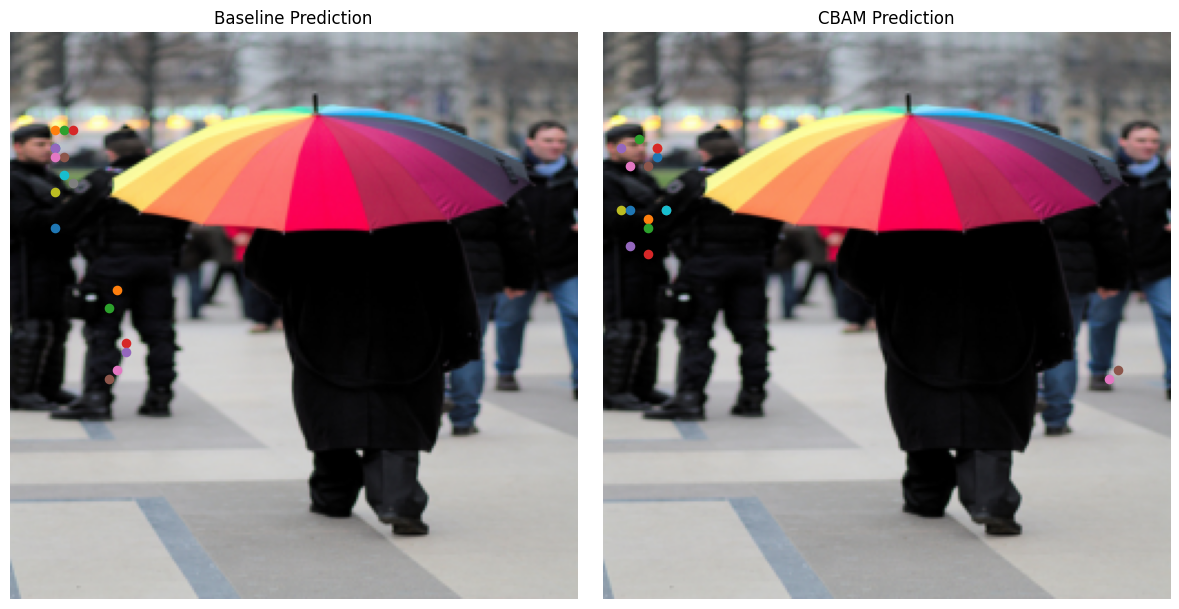

In [21]:
def visualize_comparison(idx=10):
    image, _ = val_dataset[idx]

    img_input = image.unsqueeze(0).to(device)

    baseline_model.eval()
    cbam_model.eval()

    with torch.no_grad():
        baseline_pred = baseline_model(img_input)
        cbam_pred = cbam_model(img_input)

    baseline_pts = heatmap_to_keypoints(baseline_pred.cpu())[0]
    cbam_pts = heatmap_to_keypoints(cbam_pred.cpu())[0]

    image_np = unnormalize_image(image)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image_np)

    for x, y in baseline_pts:
        axes[0].scatter(x * 4, y * 4, s=35)

    axes[0].set_title("Baseline Prediction")
    axes[0].axis("off")

    axes[1].imshow(image_np)

    for x, y in cbam_pts:
        axes[1].scatter(x * 4, y * 4, s=35)

    axes[1].set_title("CBAM Prediction")
    axes[1].axis("off")

    plt.tight_layout()

    plt.savefig(
        "/kaggle/working/baseline_vs_cbam_prediction.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

visualize_comparison(idx=10)

## 21. Visual Comparison on Multiple Validation Images

This section visualizes the predicted keypoints of the baseline ResNet18 model and the ResNet18 + CBAM model on multiple validation images. Comparing several samples provides a broader qualitative evaluation of both models under different poses, scales, and visual conditions.

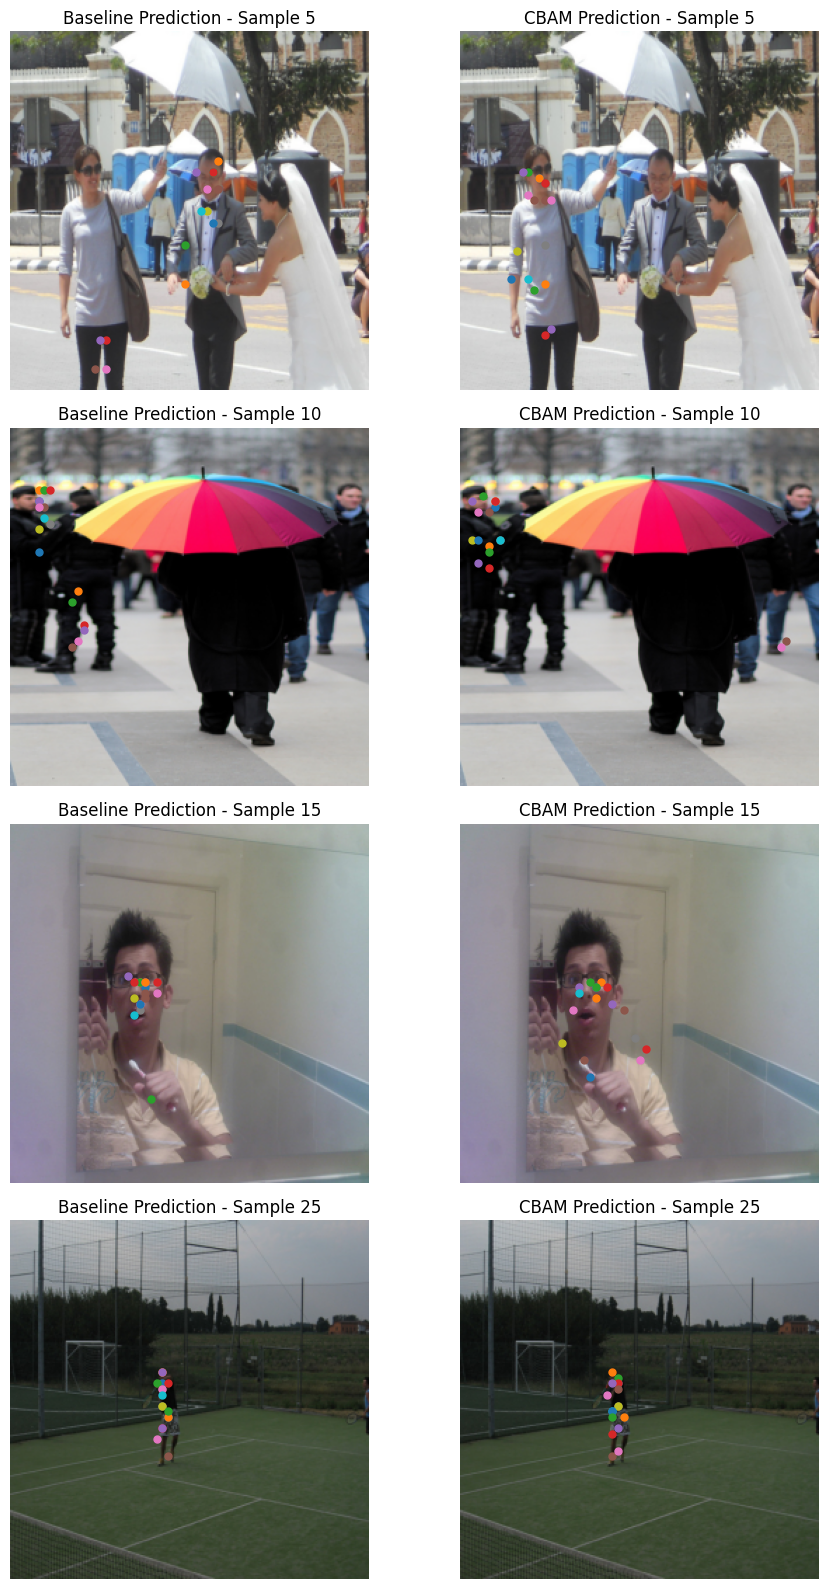

In [33]:
def visualize_multiple_comparisons(indices=[5, 10, 15, 25]):
    fig, axes = plt.subplots(len(indices), 2, figsize=(10, 4 * len(indices)))

    baseline_model.eval()
    cbam_model.eval()

    for row, idx in enumerate(indices):
        image, _ = val_dataset[idx]
        img_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            baseline_pred = baseline_model(img_input)
            cbam_pred = cbam_model(img_input)

        baseline_pts = heatmap_to_keypoints(baseline_pred.cpu())[0]
        cbam_pts = heatmap_to_keypoints(cbam_pred.cpu())[0]

        image_np = unnormalize_image(image)

        axes[row, 0].imshow(image_np)
        for x, y in baseline_pts:
            axes[row, 0].scatter(x * 4, y * 4, s=25)
        axes[row, 0].set_title(f"Baseline Prediction - Sample {idx}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(image_np)
        for x, y in cbam_pts:
            axes[row, 1].scatter(x * 4, y * 4, s=25)
        axes[row, 1].set_title(f"CBAM Prediction - Sample {idx}")
        axes[row, 1].axis("off")

    plt.tight_layout()

    plt.savefig(
        "/kaggle/working/multiple_baseline_vs_cbam_predictions.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

visualize_multiple_comparisons(indices=[5, 10, 15, 25])

In [22]:
# This cell prints the architecture summary that will be used in the final report.

print("""
Proposed Architecture:

Input Image: 256 x 256 x 3
↓
ResNet18 Backbone
↓
CBAM Attention Module
↓
Deconvolution Layer 1
↓
Deconvolution Layer 2
↓
Deconvolution Layer 3
↓
Heatmap Prediction Head
↓
17 Keypoint Heatmaps: 64 x 64
""")


Proposed Architecture:

Input Image: 256 x 256 x 3
↓
ResNet18 Backbone
↓
CBAM Attention Module
↓
Deconvolution Layer 1
↓
Deconvolution Layer 2
↓
Deconvolution Layer 3
↓
Heatmap Prediction Head
↓
17 Keypoint Heatmaps: 64 x 64



## 22. Simple PCK-Like Evaluation

This section calculates a simple PCK-like score as a supplementary evaluation metric. The metric compares predicted keypoint coordinates with ground-truth heatmap peak locations using a fixed distance threshold. This score is used only for additional observation and is not considered the main evaluation metric of the study.

In [23]:
def compute_simple_pck(model, loader, threshold=5):
    model.eval()

    total_correct = 0
    total_points = 0

    with torch.no_grad():
        for images, gt_heatmaps in loader:
            images = images.to(device)

            pred_heatmaps = model(images)

            pred_pts = heatmap_to_keypoints(pred_heatmaps.cpu())
            gt_pts = heatmap_to_keypoints(gt_heatmaps)

            dist = np.linalg.norm(
                pred_pts - gt_pts,
                axis=2
            )

            correct = dist < threshold

            total_correct += correct.sum()
            total_points += correct.size

    return total_correct / total_points


baseline_pck = compute_simple_pck(
    baseline_model,
    val_loader,
    threshold=5
)

cbam_pck = compute_simple_pck(
    cbam_model,
    val_loader,
    threshold=5
)

print("Baseline Simple PCK:", baseline_pck)
print("CBAM Simple PCK:", cbam_pck)

Baseline Simple PCK: 0.15141176470588236
CBAM Simple PCK: 0.14247058823529413


## 23. Ablation Study Setup

This section initializes the ablation study used to analyze the effects of dataset size, number of training epochs, and data augmentation on validation performance. The ablation results are stored in a list and later converted into a summary table.

In [25]:
ablation_results = []

## 24. Ablation Experiment Function

This section defines a reusable function for running ablation experiments with different model and training configurations. The function creates temporary datasets and DataLoaders, trains the selected model, evaluates validation loss after each epoch, and returns the best and final validation losses for comparison.

In [26]:
def run_ablation_experiment(
    model_class,
    model_name,
    train_samples,
    val_samples,
    epochs,
    use_augmentation,
    lr=1e-4,
    batch_size=16
):
    print("=" * 70)
    print(f"Running experiment: {model_name}")
    print(f"Train samples: {train_samples}")
    print(f"Validation samples: {val_samples}")
    print(f"Epochs: {epochs}")
    print(f"Augmentation: {use_augmentation}")
    print("=" * 70)

    temp_train_dataset = COCOPoseDataset(
        img_dir=TRAIN_IMG_DIR,
        ann_path=TRAIN_ANN,
        max_samples=train_samples,
        train=use_augmentation
    )

    temp_val_dataset = COCOPoseDataset(
        img_dir=VAL_IMG_DIR,
        ann_path=VAL_ANN,
        max_samples=val_samples,
        train=False
    )

    temp_train_loader = DataLoader(
        temp_train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    temp_val_loader = DataLoader(
        temp_val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    model = model_class().to(device)

    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        print(f"\n{model_name} - Epoch {epoch + 1}/{epochs}")

        train_loss = train_one_epoch(
            model,
            temp_train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss = validate_one_epoch(
            model,
            temp_val_loader,
            criterion,
            device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Train Loss: {train_loss:.6f}")
        print(f"Validation Loss: {val_loss:.6f}")

    best_val_loss = min(val_losses)
    final_val_loss = val_losses[-1]

    result = {
        "Model": model_name,
        "Train Samples": train_samples,
        "Validation Samples": val_samples,
        "Epochs": epochs,
        "Augmentation": "Yes" if use_augmentation else "No",
        "Best Validation Loss": best_val_loss,
        "Final Validation Loss": final_val_loss
    }

    return result, train_losses, val_losses

## 25. Ablation Experiment 1: Baseline Model with Smaller Dataset

This experiment trains the baseline ResNet18 model using 3,000 training samples and 500 validation samples for 10 epochs without data augmentation. This configuration serves as the initial baseline for the ablation study.

In [27]:
ablation_result_1, baseline_3000_train_losses, baseline_3000_val_losses = run_ablation_experiment(
    model_class=ResNet18PoseBaseline,
    model_name="ResNet18 Baseline",
    train_samples=3000,
    val_samples=500,
    epochs=10,
    use_augmentation=False
)

ablation_results.append(ablation_result_1)

Running experiment: ResNet18 Baseline
Train samples: 3000
Validation samples: 500
Epochs: 10
Augmentation: False

ResNet18 Baseline - Epoch 1/10


100%|██████████| 32/32 [00:03<00:00, 10.02it/s]


Train Loss: 0.012544
Validation Loss: 0.002480

ResNet18 Baseline - Epoch 2/10


100%|██████████| 32/32 [00:03<00:00, 10.07it/s]


Train Loss: 0.002230
Validation Loss: 0.002099

ResNet18 Baseline - Epoch 3/10


...

Train Loss: 0.002010
Validation Loss: 0.002981

ResNet18 Baseline - Epoch 9/10


100%|██████████| 32/32 [00:03<00:00,  9.86it/s]


Train Loss: 0.002025
Validation Loss: 0.001977

ResNet18 Baseline - Epoch 10/10


100%|██████████| 32/32 [00:03<00:00,  9.89it/s]


Train Loss: 0.001975
Validation Loss: 0.001986


## 26. Ablation Experiment 2: CBAM Model with Smaller Dataset

This experiment trains the ResNet18 + CBAM model using the same settings as the first ablation experiment: 3,000 training samples, 500 validation samples, 10 epochs, and no data augmentation. This setup allows a direct comparison between the baseline model and the CBAM-enhanced model under identical conditions.

In [28]:
ablation_result_2, cbam_3000_train_losses, cbam_3000_val_losses = run_ablation_experiment(
    model_class=ResNet18CBAMPose,
    model_name="ResNet18 + CBAM",
    train_samples=3000,
    val_samples=500,
    epochs=10,
    use_augmentation=False
)

ablation_results.append(ablation_result_2)

Running experiment: ResNet18 + CBAM
Train samples: 3000
Validation samples: 500
Epochs: 10
Augmentation: False

ResNet18 + CBAM - Epoch 1/10


100%|██████████| 32/32 [00:03<00:00,  9.69it/s]


Train Loss: 0.014470
Validation Loss: 0.003094

ResNet18 + CBAM - Epoch 2/10


100%|██████████| 32/32 [00:03<00:00, 10.07it/s]


Train Loss: 0.002374
Validation Loss: 0.002231

ResNet18 + CBAM - Epoch 3/10


...

Train Loss: 0.001992
Validation Loss: 0.001964

ResNet18 + CBAM - Epoch 9/10


100%|██████████| 32/32 [00:03<00:00,  9.78it/s]


Train Loss: 0.001988
Validation Loss: 0.001972

ResNet18 + CBAM - Epoch 10/10


100%|██████████| 32/32 [00:03<00:00,  9.49it/s]


Train Loss: 0.001987
Validation Loss: 0.001995


## 27. Ablation Experiment 3: Final CBAM Configuration

This section adds the final ResNet18 + CBAM training configuration to the ablation results. Unlike the first two ablation experiments, this configuration uses 5,000 training samples, 15 epochs, and horizontal flip augmentation. The best and final validation losses are recorded for comparison.

In [29]:
final_cbam_best_val = min(cbam_val_losses)
final_cbam_final_val = cbam_val_losses[-1]

ablation_results.append({
    "Model": "ResNet18 + CBAM",
    "Train Samples": 5000,
    "Validation Samples": 500,
    "Epochs": 15,
    "Augmentation": "Yes",
    "Best Validation Loss": final_cbam_best_val,
    "Final Validation Loss": final_cbam_final_val
})

## 28. Ablation Study Results Table

This section converts the collected ablation experiment results into a DataFrame. The table summarizes the effect of model type, dataset size, number of epochs, and data augmentation on validation performance.

In [30]:
ablation_df = pd.DataFrame(ablation_results)

ablation_df

,Model,Train Samples,Validation Samples,Epochs,Augmentation,Best Validation Loss,Final Validation Loss
0,ResNet18 Baseline,3000,500,10,No,0.001970,0.001986
1,ResNet18 + CBAM,3000,500,10,No,0.001964,0.001995
2,ResNet18 + CBAM,5000,500,15,Yes,0.001866,0.001899


In [31]:
ablation_df.to_csv(
    "/kaggle/working/ablation_study_results.csv",
    index=False
)

print("Ablation study results saved.")

Ablation study results saved.


## 29. Visualization of Ablation Study Results

This section visualizes the ablation study results using a bar chart. The figure compares the best validation loss values obtained under different model and training configurations, making it easier to observe the effects of dataset size, number of epochs, and data augmentation on performance.

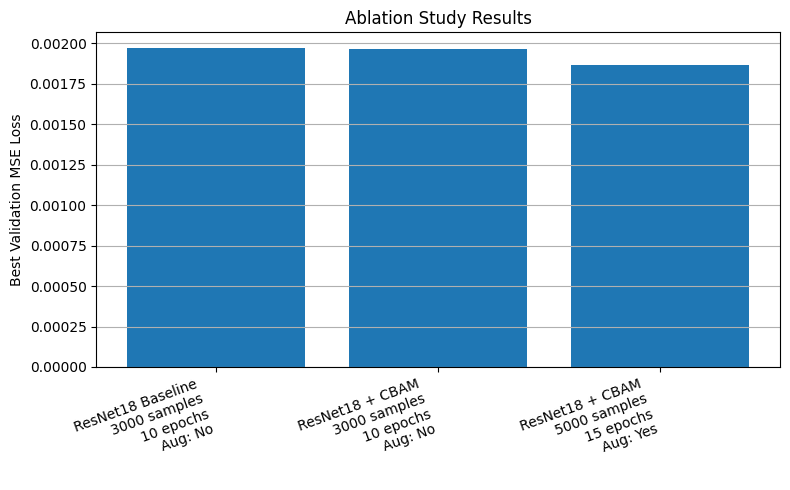

In [32]:
plt.figure(figsize=(8, 5))

labels = [
    f"{row['Model']}\n{row['Train Samples']} samples\n{row['Epochs']} epochs\nAug: {row['Augmentation']}"
    for _, row in ablation_df.iterrows()
]

plt.bar(
    labels,
    ablation_df["Best Validation Loss"]
)

plt.ylabel("Best Validation MSE Loss")
plt.title("Ablation Study Results")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/ablation_study_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 30. Overall Summary

This notebook implemented and compared two lightweight human pose estimation models using the COCO 2017 Keypoints dataset. The first model was a baseline ResNet18-based pose estimation network, while the second model integrated a Convolutional Block Attention Module (CBAM) into the same architecture.

The models were trained to predict 17 keypoint heatmaps using MSE loss and the Adam optimizer. Experimental results showed that the ResNet18 + CBAM model achieved a slightly lower final validation loss than the baseline model while adding only a small number of additional parameters. The ablation study also demonstrated that increasing the training dataset size, extending the number of epochs, and applying horizontal flip augmentation improved validation performance.

Overall, the results suggest that CBAM can provide a computationally efficient improvement for lightweight human pose estimation models. The implementation, visualizations, quantitative results, and ablation study presented in this notebook support the findings discussed in the final project report.
```
